# EDA de référence NutriScope (TP 10)

Données : Open Food Facts, © Open Food Facts contributors — ODbL.

Le notebook se rejoue de haut en bas (`jupyter nbconvert --to notebook --execute --inplace notebooks/eda_reference.ipynb`). Les calculs sont dans `src/eda_lib.py` et testés dans `tests/test_eda_lib.py` ; ici on trace et on interprète. Chaque section suit le même gabarit : question, méthode, résultat, trois lignes, décision.

In [1]:
import sys
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

# racine du dépôt, que le notebook soit lancé depuis la racine ou depuis notebooks/
RACINE = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "eda_lib.py").exists())
sys.path.insert(0, str(RACINE))

from src import eda_lib
from src.cleaning import lire_brut

rng = np.random.default_rng(eda_lib.GRAINE)
FIGURES = RACINE / "notebooks" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

# une seule couleur pour les mesures, du gris pour le contexte, une échelle bleu -> rouge pour les grades
BLEU, ORANGE, GRIS, ENCRE, ENCRE_2 = "#2a78d6", "#eb6834", "#c3c2b7", "#0b0b0b", "#52514e"
COULEURS_GRADES = {"a": "#184f95", "b": "#6da7ec", "c": "#d6d5cd", "d": "#e66767", "e": "#a81f1f"}
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": GRIS,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelcolor": ENCRE_2, "xtick.color": ENCRE_2, "ytick.color": ENCRE_2,
    "grid.color": "#e1e0d9", "font.size": 9,
})


def figure(fig, nom):
    """Sauvegarde la figure dans notebooks/figures/ puis affiche le PNG."""
    chemin = FIGURES / f"{nom}.png"
    fig.savefig(chemin, dpi=120, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=str(chemin)))

## 0. Données

**Cas dégradé.** Le TP 9 n'est pas terminé : il manque la déduplication, le traitement des catégories et la stratégie de manquants. On applique donc le nettoyage minimal du module 3.3 (`eda_lib.nettoyage_minimal`) :

- doublons de codes-barres : première occurrence gardée ;
- nutriment hors 0–100 g/100 g : ligne écartée ;
- énergie hors 0–900 kcal/100 g : ligne écartée ;
- les manquants sont conservés.

Les produits sans rayon ou de rayon `unknown` restent dans le périmètre mais sont écartés des comparaisons par rayon (`eda_lib.rayons_connus`).

Ce nettoyage sera remplacé par `src.cleaning.nettoyer` quand le TP 9 sera livré : seule la cellule ci-dessous change.

In [2]:
brut = lire_brut(RACINE / "data" / "echantillon_france.csv")
perimetre = eda_lib.nettoyage_minimal(brut)      # à remplacer par nettoyer(brut) (TP 9)
par_rayon = eda_lib.rayons_connus(perimetre)

inconnus = len(perimetre) - len(par_rayon)
print(f"brut          : {len(brut):>6} produits")
print(f"périmètre     : {len(perimetre):>6} produits")
print(f"rayon connu   : {len(par_rayon):>6} produits")
print(f"rayon inconnu : {inconnus:>6} produits ({inconnus / len(perimetre):.1%} du périmètre)")

brut          :   8689 produits
périmètre     :   8400 produits
rayon connu   :   6674 produits
rayon inconnu :   1726 produits (20.5% du périmètre)


## 1. Distributions des nutriments clés par rayon

### Question

Que mange-t-on réellement dans le périmètre ? Les rayons se ressemblent-ils, ou chacun a-t-il son profil ?

### Méthode

- `resume_univarie` sur sucres, sel et énergie : on regarde la forme avant de comparer.
- `profil_par_rayon` : médiane et quartiles par rayon, les groupes de moins de 30 valeurs sont écartés.
- `croisement_rayon_grade` en % par ligne et V de Cramér, sur les grades a–e uniquement.

Tout est calculé sur les 6 674 produits de rayon connu.

### Résultat

In [3]:
NUTS = ["sugars_100g", "salt_100g", "energy-kcal_100g"]
LIBELLES = {"sugars_100g": "Sucres (g/100 g)", "salt_100g": "Sel (g/100 g)", "energy-kcal_100g": "Énergie (kcal/100 g)"}

resume = pd.DataFrame({c: eda_lib.resume_univarie(par_rayon[c]) for c in NUTS}).T
resume.round(2)

,n,manquants,moyenne,mediane,ecart_type,IQR,MAD,CV,asymetrie,aplatissement,p05,Q1,Q3,p95,min,max
sugars_100g,5546.0,1128.0,12.94,3.0,19.79,15.60,3.00,1.53,1.89,2.94,0.0,0.60,16.2,57.50,0.0,100.0
salt_100g,5418.0,1256.0,1.07,0.5,2.37,1.25,0.49,2.23,11.13,240.78,0.0,0.05,1.3,3.67,0.0,77.5
energy-kcal_100g,5599.0,1075.0,275.07,254.0,192.81,286.00,143.00,0.70,0.71,0.25,23.0,111.00,397.0,597.00,0.0,900.0


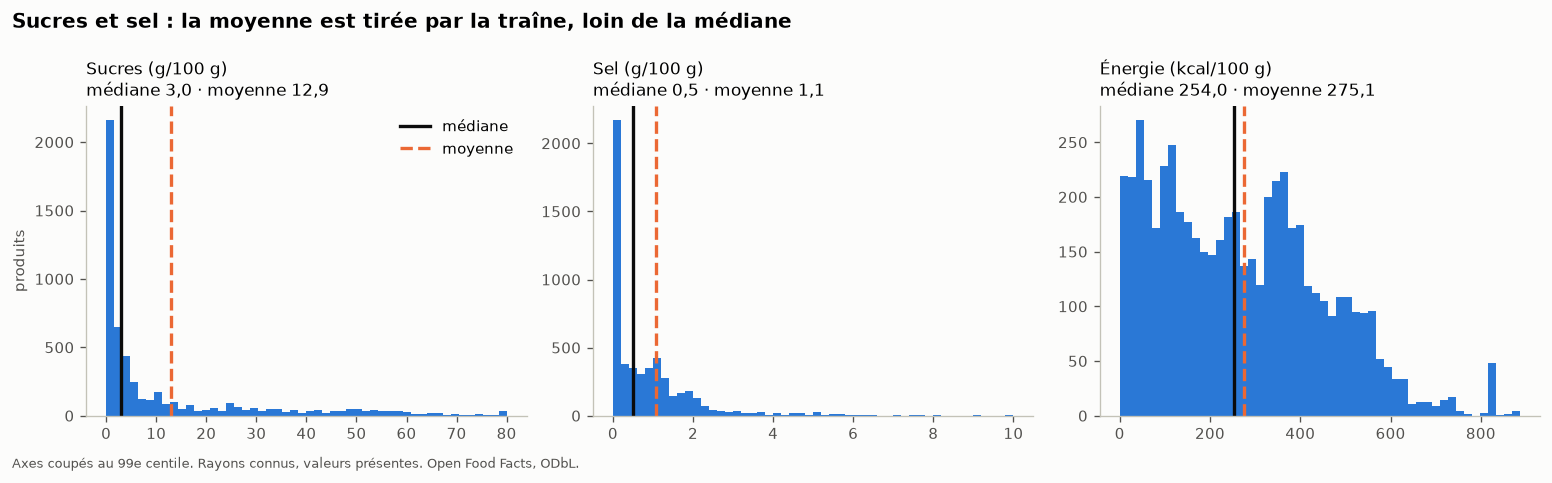

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, c in zip(axes, NUTS):
    x = par_rayon[c].dropna()
    ax.hist(x[x <= x.quantile(0.99)], bins=50, color=BLEU)
    ax.axvline(resume.loc[c, "mediane"], color=ENCRE, linewidth=2, label="médiane")
    ax.axvline(resume.loc[c, "moyenne"], color=ORANGE, linewidth=2, linestyle="--", label="moyenne")
    titre = f"{LIBELLES[c]}\nmédiane {resume.loc[c, 'mediane']:.1f} · moyenne {resume.loc[c, 'moyenne']:.1f}"
    ax.set_title(titre.replace(".", ","), fontweight="normal", fontsize=10)
axes[0].set_ylabel("produits")
axes[0].legend(frameon=False)
fig.suptitle("Sucres et sel : la moyenne est tirée par la traîne, loin de la médiane",
             x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.text(0.01, -0.02, "Axes coupés au 99e centile. Rayons connus, valeurs présentes. Open Food Facts, ODbL.",
         color=ENCRE_2, fontsize=8)
fig.tight_layout()
figure(fig, "1-histogrammes-nutriments")

**Trois lignes.**

1. Sucres et sel sont très asymétriques : la moyenne vaut quatre fois la médiane pour les sucres (12,9 g contre 3,0 g) et deux fois pour le sel (1,07 g contre 0,5 g).
2. L'énergie est la seule des trois à peu près symétrique (médiane 254 kcal, moyenne 275 kcal).
3. Entre 16 % et 19 % des valeurs manquent selon le nutriment, et le sel garde un maximum à 77,5 g/100 g : à examiner en section 4.

In [5]:
profil = eda_lib.profil_par_rayon(par_rayon, NUTS)
ecartes = eda_lib.rayons_ecartes(par_rayon, NUTS)
print(f"groupes écartés (moins de 30 valeurs) : {len(ecartes)}")
profil.loc["sugars_100g"].sort_values("mediane", ascending=False).round(1)

groupes écartés (moins de 30 valeurs) : 0


,n,Q1,mediane,Q3,moyenne
rayon,,,,,
Sugary snacks,1185,24.0,38.0,53.0,39.4
Beverages,452,0.1,6.1,10.5,10.1
Baby foods,50,2.3,5.6,10.5,10.3
Fruits and vegetables,373,1.2,4.6,15.0,15.3
Milk and dairy products,666,0.5,3.7,11.8,7.2
Cereals and potatoes,606,1.0,2.7,4.5,4.9
Salty snacks,332,1.0,2.6,4.5,3.6
Composite foods,457,1.1,2.2,3.4,3.0
Fat and sauces,442,0.0,1.5,6.0,6.4


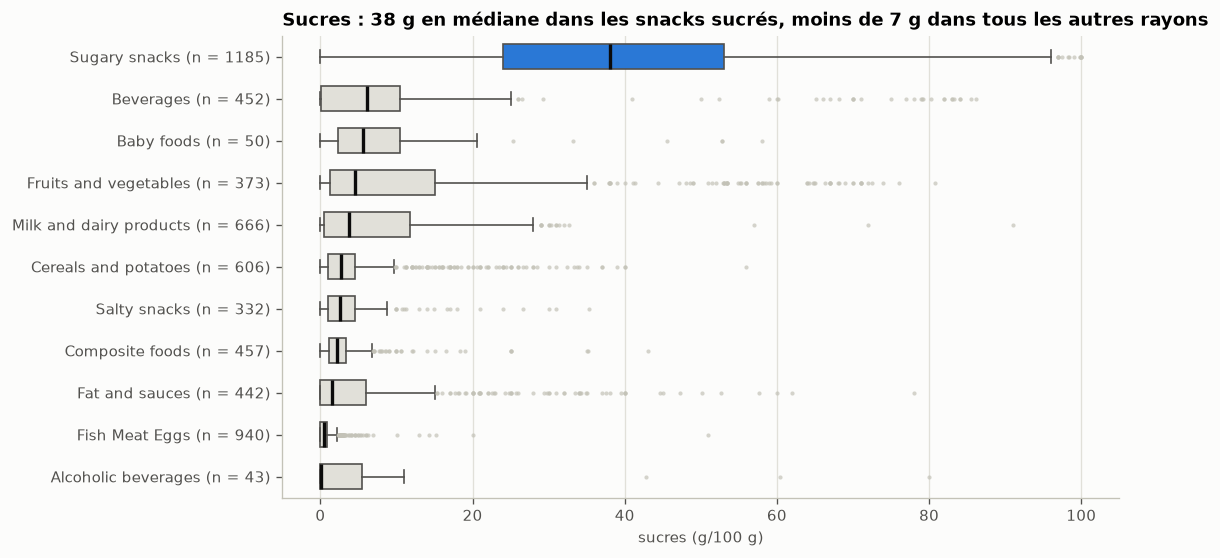

In [6]:
sucres = profil.loc["sugars_100g"].sort_values("mediane")
series = [par_rayon.loc[par_rayon[eda_lib.RAYON] == r, "sugars_100g"].dropna() for r in sucres.index]

fig, ax = plt.subplots(figsize=(9, 5))
boites = ax.boxplot(series, orientation="horizontal", patch_artist=True, widths=0.6,
                    tick_labels=[f"{r} (n = {int(n)})" for r, n in sucres["n"].items()],
                    medianprops={"color": ENCRE, "linewidth": 2},
                    whiskerprops={"color": ENCRE_2}, capprops={"color": ENCRE_2},
                    flierprops={"marker": "o", "markersize": 2.5, "markerfacecolor": GRIS,
                                "markeredgecolor": "none", "alpha": 0.7})
for boite, rayon in zip(boites["boxes"], sucres.index):
    boite.set(facecolor=BLEU if rayon == "Sugary snacks" else "#e1e0d9", edgecolor=ENCRE_2)
ax.set_xlabel("sucres (g/100 g)")
ax.grid(axis="x")
ax.set_title("Sucres : 38 g en médiane dans les snacks sucrés, moins de 7 g dans tous les autres rayons")
figure(fig, "1-boites-sucres-par-rayon")

**Trois lignes.**

1. Les snacks sucrés sont à part : 38 g de sucres en médiane (quartiles 24 et 53 g), six fois la médiane du rayon suivant, les boissons (6,1 g).
2. Dans les autres rayons la boîte est basse mais les extrêmes montent haut : en fruits et légumes la moyenne (15,3 g) vaut trois fois la médiane (4,6 g).
3. Aucun groupe n'est écarté par le seuil de 30, mais les boissons alcoolisées (n = 43) et les aliments pour bébés (n = 50) restent des petits rayons : à commenter avec prudence.

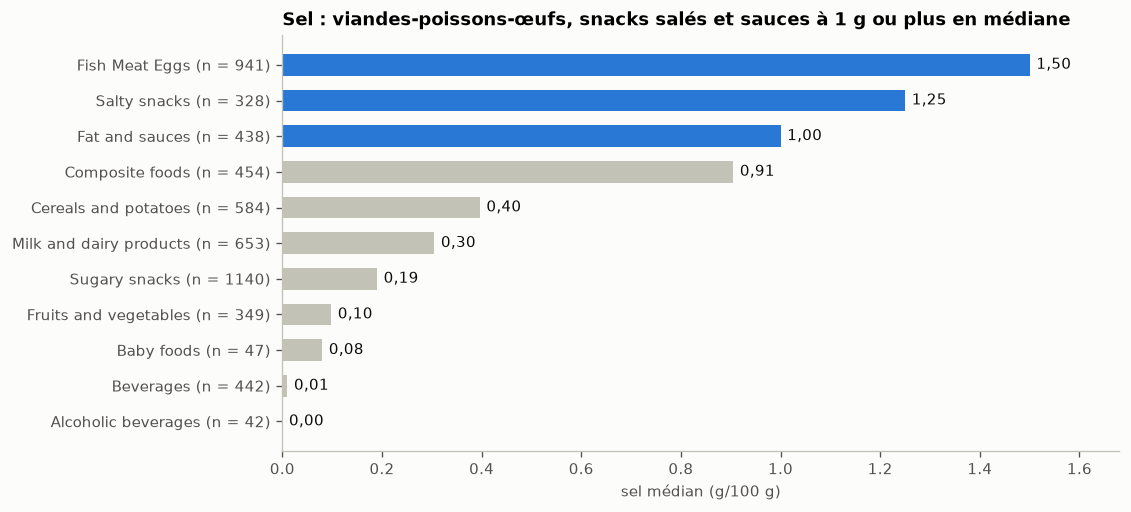

In [7]:
sel = profil.loc["salt_100g"].sort_values("mediane")

fig, ax = plt.subplots(figsize=(9, 4.5))
barres = ax.barh([f"{r} (n = {int(n)})" for r, n in sel["n"].items()], sel["mediane"], height=0.6,
                 color=[BLEU if m >= 1 else GRIS for m in sel["mediane"]])
ax.bar_label(barres, labels=[f"{m:.2f}".replace(".", ",") for m in sel["mediane"]], padding=4, color=ENCRE)
ax.set_xlabel("sel médian (g/100 g)")
ax.set_xlim(0, sel["mediane"].max() * 1.12)
ax.set_title("Sel : viandes-poissons-œufs, snacks salés et sauces à 1 g ou plus en médiane")
figure(fig, "1-sel-median-par-rayon")

**Trois lignes.**

1. Trois rayons atteignent 1 g de sel en médiane : viandes-poissons-œufs (1,5 g), snacks salés (1,25 g), matières grasses et sauces (1,0 g).
2. Les boissons sont à 0,01 g : le sel n'y dit presque rien, les sucres y disent tout.
3. Le classement par sel n'est pas celui par sucres : les snacks sucrés, premiers en sucres, sont à 0,19 g de sel.

In [8]:
table = eda_lib.croisement_rayon_grade(par_rayon)
parts = eda_lib.parts_par_ligne(table)
v = eda_lib.v_cramer(table)
print(f"{int(table.to_numpy().sum())} produits notés a–e dans {len(table)} rayons ; V de Cramér = {v:.2f}")
parts.round(1).assign(n=table.sum(axis=1))

5149 produits notés a–e dans 9 rayons ; V de Cramér = 0.34


nutriscore_grade,a,b,c,d,e,n
pnns_groups_1,,,,,,
Beverages,6.9,24.4,27.6,17.2,23.9,377
Cereals and potatoes,33.3,19.8,26.3,16.8,3.9,571
Composite foods,8.4,15.9,48.3,23.7,3.7,464
Fat and sauces,6.4,20.6,20.4,16.0,36.6,407
Fish Meat Eggs,20.0,9.2,13.3,27.4,30.2,928
Fruits and vegetables,50.3,14.2,16.3,12.5,6.7,344
Milk and dairy products,5.2,7.2,30.6,45.8,11.2,635
Salty snacks,9.8,9.8,20.0,29.5,30.8,325
Sugary snacks,0.9,0.8,5.6,26.6,66.1,1098


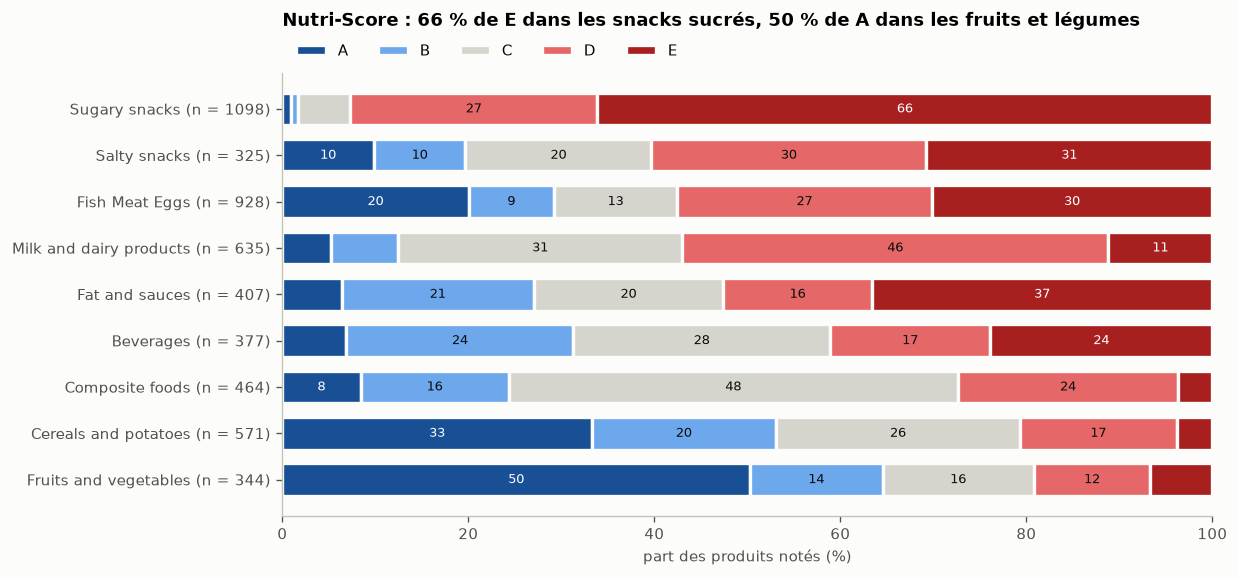

In [9]:
ordre = (parts["d"] + parts["e"]).sort_values().index
fig, ax = plt.subplots(figsize=(10, 4.8))
gauche = np.zeros(len(ordre))
etiquettes = [f"{r} (n = {table.loc[r].sum()})" for r in ordre]
for grade in eda_lib.GRADES:
    valeurs = parts.loc[ordre, grade].to_numpy()
    barres = ax.barh(etiquettes, valeurs, left=gauche, height=0.7, label=grade.upper(),
                     color=COULEURS_GRADES[grade], edgecolor="#fcfcfb", linewidth=2)
    ax.bar_label(barres, labels=[f"{x:.0f}" if x >= 8 else "" for x in valeurs], label_type="center",
                 color="white" if grade in ("a", "e") else ENCRE, fontsize=8)
    gauche += valeurs
ax.set_xlim(0, 100)
ax.set_xlabel("part des produits notés (%)")
ax.legend(ncol=5, frameon=False, loc="lower left", bbox_to_anchor=(0, 1.0))
ax.set_title("Nutri-Score : 66 % de E dans les snacks sucrés, 50 % de A dans les fruits et légumes", pad=28)
figure(fig, "1-grades-par-rayon")

**Trois lignes.**

1. La répartition des grades change du tout au tout d'un rayon à l'autre : 66 % de E dans les snacks sucrés (93 % de D ou E), 50 % de A dans les fruits et légumes.
2. Le V de Cramér vaut 0,34 sur 5 149 produits notés : le rayon et le grade sont liés, sans que le rayon suffise à donner la note.
3. 23 % des produits de rayon connu n'ont pas de grade a–e (`unknown`, `not-applicable`) ; les boissons alcoolisées (2 produits notés) et les aliments pour bébés (aucun) sortent de ce croisement.

### Décision

1. **TP 14** : le modèle recevra le rayon (`pnns_groups_1`) comme variable.
2. **Suite de l'EDA** : médianes et quartiles partout ; la moyenne n'est citée qu'avec un commentaire sur les extrêmes. Pour les sucres et le sel, une transformation `log1p` sera à tester au TP 14.
3. **TP 11** : le message d'ouverture est trouvé — « la moitié des snacks sucrés dépasse 38 g de sucres pour 100 g, six fois plus que le rayon suivant ».

## 2. Complétude et qualité par rayon et par marque

### Question

Où les données sont-elles fiables, où faudra-t-il être prudent ?

### Méthode

À compléter.

### Résultat

In [10]:
# à compléter

### Trois lignes

À compléter.

### Décision

À compléter.

## 3. Corrélations entre nutriments et Nutri-Score

### Question

Quels nutriments portent un signal pour le modèle du TP 14 ?

### Méthode

À compléter.

### Résultat

In [11]:
# à compléter

### Trois lignes

À compléter.

### Décision

À compléter.

## 4. Valeurs extrêmes restantes

### Question

Les extrêmes qui restent sont-ils vrais ou résiduels ?

### Méthode

À compléter.

### Résultat

In [12]:
# à compléter

### Trois lignes

À compléter.

### Décision

À compléter.

## 5. Hypothèses et registre

### Question

Quelles hypothèses tiennent une fois stratifiées par rayon ?

### Méthode

À compléter.

### Résultat

In [13]:
# à compléter

### Trois lignes

À compléter.

### Décision

À compléter.

## 6. Synthèse

La synthèse d'une page est dans `docs/data/synthese_eda.md`.

À compléter.